# Workshop: S2S – Accessing Sub-National Data

**Duration:** 30 minutes  
**Type:** Hands-on exercise  
**Presenter:** Gabe

---

### What you’ll learn

1. How to install and set up the Space2Stats Python client
2. How to fetch administrative boundaries for any country
3. How to discover pre-computed sub-national datasets on the World Bank DDH
4. How to query and visualize population, nighttime lights, urbanization, and flood exposure data

### Key takeaway

> *Pre-computed ADM2 summaries on the World Bank Data Distribution Hub (DDH) give you ready-to-use sub-national indicators — no rasters, no zonal stats, no GIS software required.*

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://githubtocolab.com/worldbank/DECAT_Space2Stats/blob/glevin_workshop_prep/workshops/01_accessing_subnational_data.ipynb)

In [40]:
# Install the client
%pip install space2stats-client matplotlib mapclassify

Note: you may need to restart the kernel to use updated packages.


In [54]:
from space2stats_client import Space2StatsClient
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

# Initialize the client — that’s it, no auth required
client = Space2StatsClient()

---
## Part 2: Fetch Admin Boundaries (5 min)

The client has a built-in helper to fetch official World Bank administrative boundaries.

Number of districts: 30


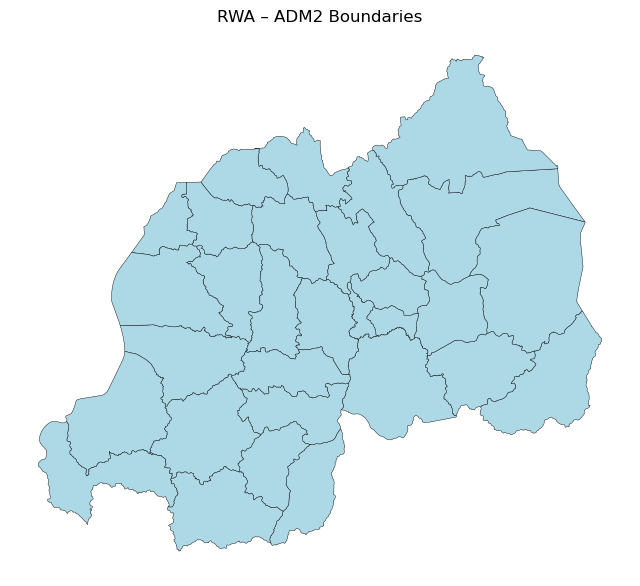

In [55]:
# Fetch ADM2 (district-level) boundaries for Rwanda
ISO3 = "RWA"
boundaries = client.fetch_admin_boundaries(ISO3, "ADM2")
print(f"Number of districts: {len(boundaries)}")
boundaries.plot(figsize=(8, 8), edgecolor="black", linewidth=0.3, color="lightblue")
plt.title(f"{ISO3} – ADM2 Boundaries")
plt.axis("off")
plt.show()

In [56]:
# What does the boundary data look like?
boundaries.head()

,FID,ISO_A3,ISO_A2,WB_A3,WB_REGION,WB_STATUS,NAM_0,NAM_1,ADM1CD_c,GEOM_SRCE,NAM_2,ADM2CD_c,GlobalID,Shape__Area,Shape__Length,geometry
0,8834,RWA,RW,RWA,AFR,Member State,Rwanda,East/Iburasirazuba,RWA001,WB GAD,Bugesera,RWA001001,2dff86e1-6f8f-4537-b099-881600daa753,0.104415,1.682798,"POLYGON ((30.101 -2.42411, 30.09686 -2.42304, ..."
1,8835,RWA,RW,RWA,AFR,Member State,Rwanda,East/Iburasirazuba,RWA001,WB GAD,Gatsibo,RWA001002,88559a06-bef7-4ff4-a176-f34a8663567b,0.128731,2.190899,"POLYGON ((30.7401 -1.45849, 30.74105 -1.47952,..."
2,8836,RWA,RW,RWA,AFR,Member State,Rwanda,East/Iburasirazuba,RWA001,WB GAD,Kayonza,RWA001003,5d736e06-fcf3-435e-b2ed-2b249be630c7,0.157032,1.834130,"POLYGON ((30.41977 -1.84642, 30.42126 -1.84434..."
3,8837,RWA,RW,RWA,AFR,Member State,Rwanda,East/Iburasirazuba,RWA001,WB GAD,Kirehe,RWA001004,0079747c-2f3c-4b03-8f7d-6109d3a08a81,0.096008,1.711863,"POLYGON ((30.5448 -2.41358, 30.53877 -2.41036,..."
4,8838,RWA,RW,RWA,AFR,Member State,Rwanda,East/Iburasirazuba,RWA001,WB GAD,Ngoma,RWA001005,5df66628-0bfc-4b5d-adc0-e38fefc7913b,0.070554,1.415620,"POLYGON ((30.46021 -2.31926, 30.45802 -2.31808..."


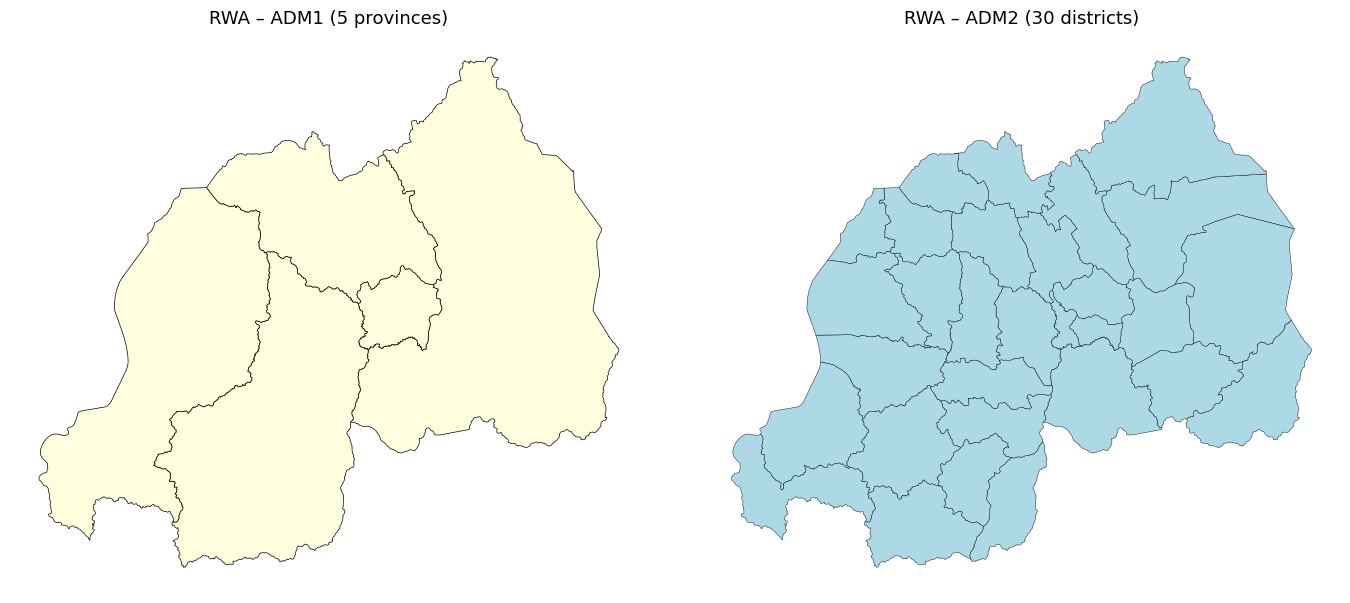

In [57]:
# You can also fetch ADM1 (province-level) boundaries
adm1 = client.fetch_admin_boundaries(ISO3, "ADM1")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

adm1.plot(ax=axes[0], edgecolor="black", linewidth=0.5, color="lightyellow")
axes[0].set_title(f"{ISO3} – ADM1 ({len(adm1)} provinces)", fontsize=13)
axes[0].axis("off")

boundaries.plot(ax=axes[1], edgecolor="black", linewidth=0.3, color="lightblue")
axes[1].set_title(f"{ISO3} – ADM2 ({len(boundaries)} districts)", fontsize=13)
axes[1].axis("off")

plt.tight_layout()
plt.show()

---
## Part 3: Discover DDH Datasets (5 min)

The [World Bank Development Data Hub (DDH)](https://datacatalog.worldbank.org/) hosts pre-computed ADM2-level summaries derived from Space2Stats. These are ready-to-use — no hexagons, no spatial joins, just district-level indicators.

Let’s see what’s available.

In [58]:
# What pre-computed ADM2 datasets are available?
client.get_adm2_dataset_info()

,dataset,resource_id,description,url
0,urbanization,DR0095357,Urban and rural settlement data - GHS settleme...,https://datacatalogapi.worldbank.org/ddhxext/v...
1,nighttimelights,DR0095356,Nighttime lights intensity data - satellite-de...,https://datacatalogapi.worldbank.org/ddhxext/v...
2,population,DR0095354,Population statistics - demographic data,https://datacatalogapi.worldbank.org/ddhxext/v...
3,flood_exposure,DR0095355,Flood exposure risk data - flood hazard and ex...,https://datacatalogapi.worldbank.org/ddhxext/v...


Four datasets are currently available:

| Dataset | Description |
|---------|-------------|
| `population` | Gridded population by gender and age group (WorldPop 2020) |
| `nighttimelights` | Satellite-measured luminosity (VIIRS, 2012–2024) |
| `urbanization` | Settlement classification (GHS-SMOD) |
| `flood_exposure` | Population exposed to flood risk (Fathom v3) |

---
## Part 4: Query DDH Summaries (15 min)

### 4a. Population

In [59]:
pop = client.get_adm2_summaries("population", iso3_filter="RWA")

# DDH API returns strings — convert numeric columns
num_cols = [c for c in pop.columns if c != "ADM2CD_c" and c != "ISO3"]
pop[num_cols] = pop[num_cols].apply(pd.to_numeric)

print(f"Columns: {len(pop.columns)}")
pop.head(3)

Fetching population data from World Bank DDH API...
Filtering by ISO3: RWA
Retrieved 30 records (total available: 30)
Columns: 41


,ADM2CD_c,sum_pop_f_0_2020,sum_pop_f_10_2020,sum_pop_f_15_2020,sum_pop_f_1_2020,sum_pop_f_20_2020,sum_pop_f_25_2020,sum_pop_f_30_2020,sum_pop_f_35_2020,sum_pop_f_40_2020,...,sum_pop_m_5_2020,sum_pop_m_60_2020,sum_pop_m_65_2020,sum_pop_m_70_2020,sum_pop_m_75_2020,sum_pop_m_80_2020,sum_pop_f_2020,sum_pop_m_2020,sum_pop_2020,ISO3
0,RWA001001,6029.059495,33742.789497,35072.459843,23578.313130,18454.175620,20384.008398,19559.734016,16654.135691,12699.337431,...,33902.870351,4960.560984,2942.250676,1093.649673,568.381734,513.510214,253210.026674,249045.330818,502255.357492,RWA
1,RWA001002,8370.757900,41770.161192,39528.691046,32911.351143,19179.306673,26780.373700,28104.252054,23352.939411,15857.389541,...,44732.803072,6861.790226,4596.554597,1616.119049,923.546710,851.951427,324911.487923,321979.827638,646891.315561,RWA
2,RWA001003,6539.301437,34713.744965,33538.169178,25708.297904,17505.317716,23230.125975,22653.656401,19050.347347,12784.953440,...,37376.799539,5943.435506,3748.451567,1419.146482,720.601944,714.363832,268545.962593,266683.084392,535229.046986,RWA


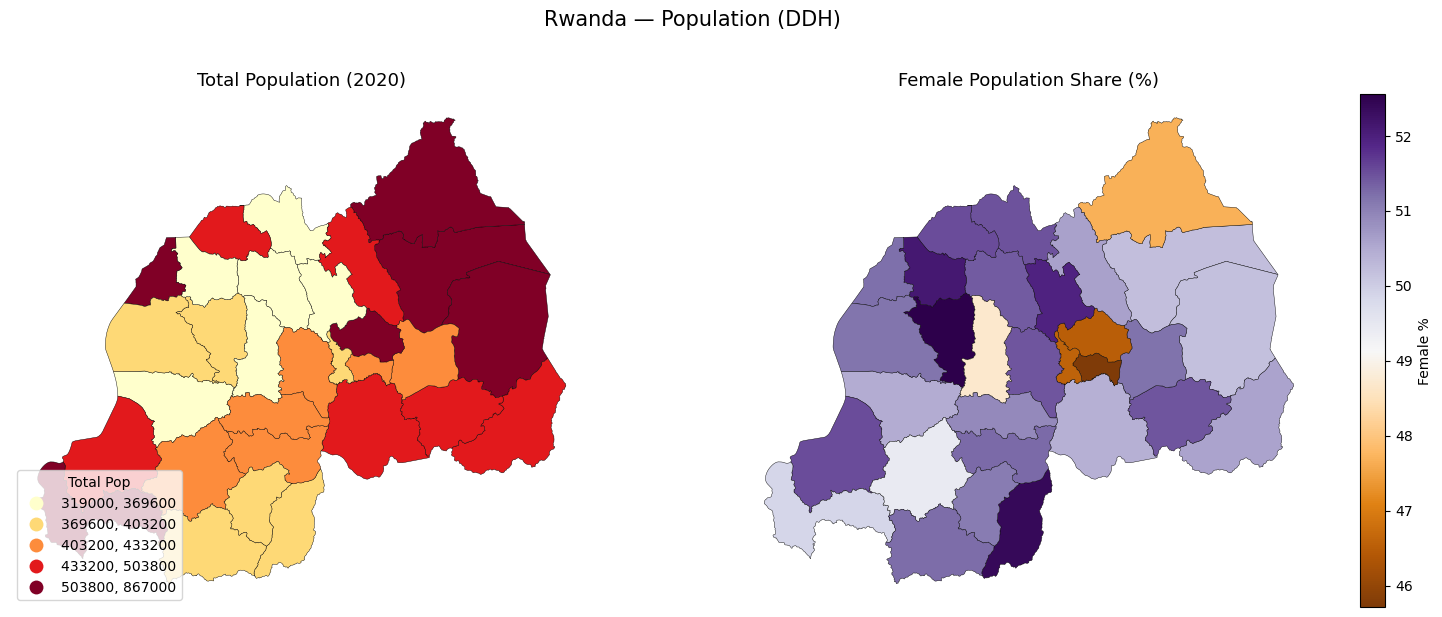

In [62]:
# Join with boundaries and map total population
pop_geo = boundaries.merge(pop, on="ADM2CD_c")

# Round population to clean numbers for display
pop_geo["sum_pop_2020"] = (pop_geo["sum_pop_2020"] / 1000).round() * 1000

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

pop_geo.plot(
    column="sum_pop_2020", cmap="YlOrRd", scheme="quantiles", k=5,
    legend=True, edgecolor="black", linewidth=0.3, ax=axes[0],
    legend_kwds={"title": "Total Pop", "loc": "lower left", "fmt": "{:.0f}"}
)
axes[0].set_title("Total Population (2020)", fontsize=13)
axes[0].axis("off")

# Female share
pop_geo["female_share"] = pop_geo["sum_pop_f_2020"] / pop_geo["sum_pop_2020"] * 100

pop_geo.plot(
    column="female_share", cmap="PuOr", legend=True,
    edgecolor="black", linewidth=0.3, ax=axes[1],
    legend_kwds={"label": "Female %"}
)
axes[1].set_title("Female Population Share (%)", fontsize=13)
axes[1].axis("off")

plt.suptitle("Rwanda — Population (DDH)", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

### 4b. Nighttime Lights

The NTL dataset has yearly columns from 2012 to 2024, making it easy to visualize trends over time.

In [63]:
ntl = client.get_adm2_summaries("nighttimelights", iso3_filter="RWA")

# DDH API returns strings — convert numeric columns
num_cols = [c for c in ntl.columns if c != "ADM2CD_c" and c != "ISO3"]
ntl[num_cols] = ntl[num_cols].apply(pd.to_numeric)

ntl.head(3)

Fetching nighttimelights data from World Bank DDH API...
Filtering by ISO3: RWA
Retrieved 30 records (total available: 30)


,ADM2CD_c,sum_viirs_ntl_2012,sum_viirs_ntl_2013,sum_viirs_ntl_2014,sum_viirs_ntl_2015,sum_viirs_ntl_2016,sum_viirs_ntl_2017,sum_viirs_ntl_2018,sum_viirs_ntl_2019,sum_viirs_ntl_2020,sum_viirs_ntl_2021,sum_viirs_ntl_2022,sum_viirs_ntl_2023,sum_viirs_ntl_2024,ISO3
0,RWA001001,2769.471570,2355.708743,3129.414188,2945.112797,3075.268948,3874.354003,3437.493715,2307.047736,3330.978921,4375.175978,5068.335215,6253.062933,3956.772916,RWA
1,RWA001002,4274.191060,16989.436066,4266.977000,5806.561232,4346.222493,4453.718577,4030.667027,2531.433064,3286.871686,3766.176953,4299.516442,5393.385719,2119.051181,RWA
2,RWA001003,5153.984483,5276.980466,8790.774240,10778.973330,5604.519920,5083.776159,4266.250025,2682.437129,3772.820982,4563.458395,4615.204806,6370.077183,2559.387674,RWA


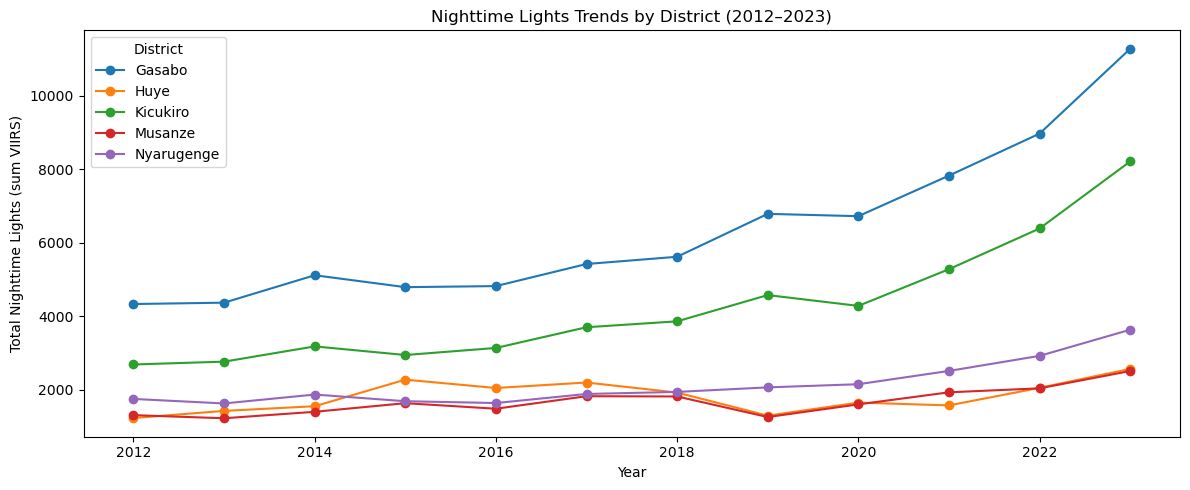

In [67]:
# Join with boundaries for district names
ntl_geo = boundaries[["ADM2CD_c", "NAM_2"]].merge(ntl, on="ADM2CD_c")

# Reshape wide-to-long for plotting (up to 2023)
ntl_cols = [c for c in ntl.columns if c.startswith("sum_viirs_ntl_") and int(c[-4:]) <= 2023]
ntl_long = ntl_geo.melt(
    id_vars=["ADM2CD_c", "NAM_2"],
    value_vars=ntl_cols,
    var_name="year_col",
    value_name="ntl"
)
ntl_long["year"] = ntl_long["year_col"].str.extract(r"(\d{4})").astype(int)

# Pick a few districts to compare
highlight = ["Kicukiro", "Gasabo", "Nyarugenge", "Musanze", "Huye"]
ntl_subset = ntl_long[ntl_long["NAM_2"].isin(highlight)]

fig, ax = plt.subplots(figsize=(12, 5))
for name, group in ntl_subset.groupby("NAM_2"):
    ax.plot(group["year"], group["ntl"], marker="o", label=name)

ax.set_xlabel("Year")
ax.set_ylabel("Total Nighttime Lights (sum VIIRS)")
ax.set_title("Nighttime Lights Trends by District (2012–2023)")
ax.legend(title="District")
plt.tight_layout()
plt.show()

### 4c. Urbanization

The urbanization dataset uses the GHS-SMOD settlement classification. Each hexagon is classified into settlement types, and both **area counts** and **population** are provided per class.

| Code | Settlement type |
|------|----------------|
| 11 | Very low density rural |
| 12 | Low density rural |
| 13 | Rural cluster |
| 21 | Suburban |
| 22 | Semi-dense urban |
| 23 | Dense urban |
| 30 | Urban centre |

In [68]:
urb = client.get_adm2_summaries("urbanization", iso3_filter="RWA")

# DDH API returns strings — convert numeric columns
num_cols = [c for c in urb.columns if c != "ADM2CD_c" and c != "ISO3"]
urb[num_cols] = urb[num_cols].apply(pd.to_numeric)

urb.head(3)

Fetching urbanization data from World Bank DDH API...
Filtering by ISO3: RWA
Retrieved 30 records (total available: 30)


,ADM2CD_c,ghs_11_count,ghs_12_count,ghs_13_count,ghs_21_count,ghs_22_count,ghs_23_count,ghs_30_count,ghs_total_count,ghs_11_pop,ghs_12_pop,ghs_13_pop,ghs_21_pop,ghs_22_pop,ghs_23_pop,ghs_30_pop,ghs_total_pop,ISO3
0,RWA001001,405.742082,321.441154,20.915505,405.315143,66.992868,28.587027,0.0,1248.993779,3284.859180,51034.905185,13017.140398,293019.426032,44692.334217,81870.597935,0.0,486919.262947,RWA
1,RWA001002,626.433283,239.296799,7.670230,671.154706,0.499581,26.509794,0.0,1571.564393,1786.604391,41513.539200,4364.693994,494092.954531,150.142853,69886.075730,0.0,611794.010701,RWA
2,RWA001003,976.847469,315.430883,24.937811,460.398252,7.028792,30.760239,0.0,1815.403446,6944.074751,46683.650897,17838.409301,339398.393806,9262.394718,95341.181956,0.0,515468.105429,RWA


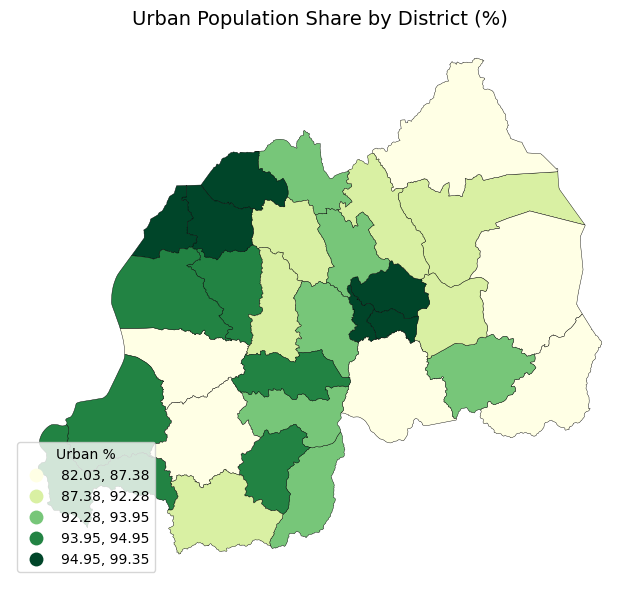

In [69]:
# Join with boundaries
urb_geo = boundaries[["ADM2CD_c", "NAM_2", "geometry"]].merge(urb, on="ADM2CD_c")
urb_geo = gpd.GeoDataFrame(urb_geo, geometry="geometry")

# Calculate urban population share (classes 21-30 are urban/suburban)
urb_geo["urban_pop"] = (
    urb_geo["ghs_21_pop"] + urb_geo["ghs_22_pop"] +
    urb_geo["ghs_23_pop"] + urb_geo["ghs_30_pop"]
)
urb_geo["urban_share"] = urb_geo["urban_pop"] / urb_geo["ghs_total_pop"] * 100

fig, ax = plt.subplots(figsize=(8, 8))
urb_geo.plot(
    column="urban_share", cmap="YlGn", scheme="quantiles", k=5,
    legend=True, edgecolor="black", linewidth=0.3, ax=ax,
    legend_kwds={"title": "Urban %", "loc": "lower left"}
)
ax.set_title("Urban Population Share by District (%)", fontsize=14)
ax.axis("off")
plt.show()

### 4d. Flood Exposure

The flood exposure dataset shows population at risk from flooding (depth > 15 cm in a 1-in-100-year event).

In [70]:
flood = client.get_adm2_summaries("flood_exposure", iso3_filter="RWA")

# DDH API returns strings — convert numeric columns
num_cols = [c for c in flood.columns if c != "ADM2CD_c" and c != "ISO3"]
flood[num_cols] = flood[num_cols].apply(pd.to_numeric)

flood.head(3)

Fetching flood_exposure data from World Bank DDH API...
Filtering by ISO3: RWA
Retrieved 30 records (total available: 30)


,ADM2CD_c,pop,pop_flood,pop_flood_pct,ISO3
0,RWA001001,502157.954925,71368.472310,4.604784,RWA
1,RWA001002,646512.149164,62618.407801,4.949082,RWA
2,RWA001003,533187.953673,46619.479917,5.150828,RWA


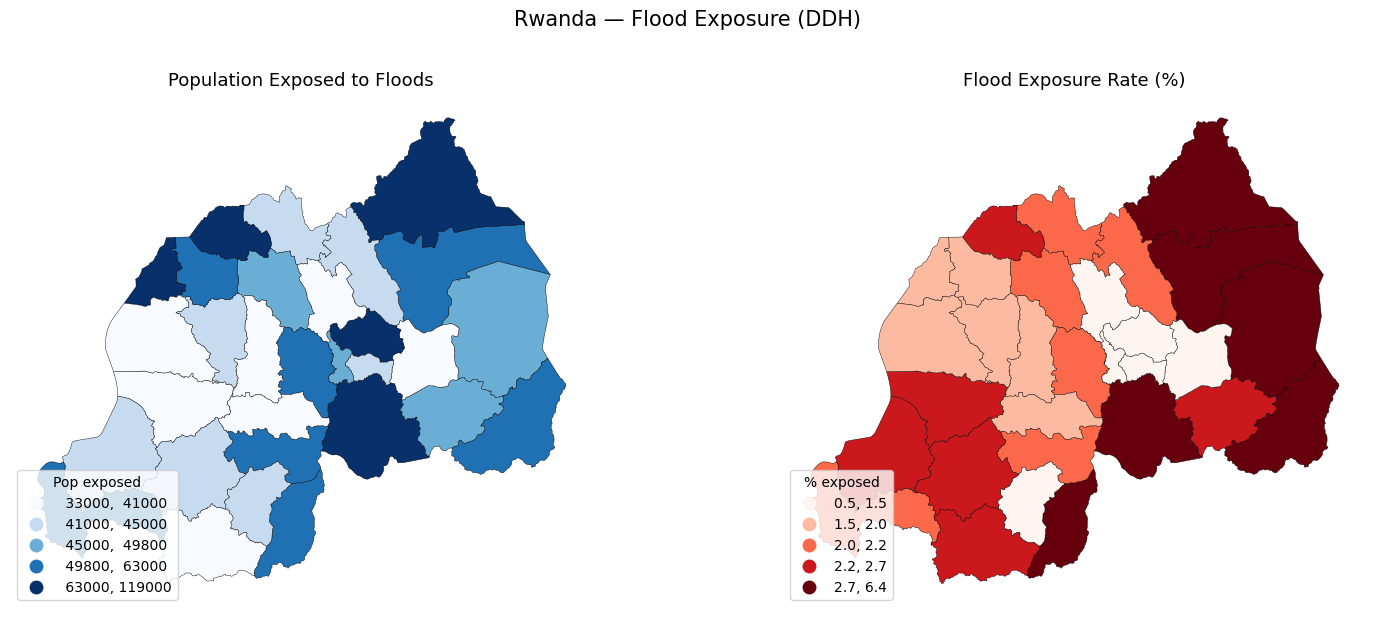

In [72]:
# Join with boundaries
flood_geo = boundaries[["ADM2CD_c", "NAM_2", "geometry"]].merge(flood, on="ADM2CD_c")
flood_geo = gpd.GeoDataFrame(flood_geo, geometry="geometry")

# Round to clean numbers
flood_geo["pop_flood"] = (flood_geo["pop_flood"] / 1000).round() * 1000

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

flood_geo.plot(
    column="pop_flood", cmap="Blues", scheme="quantiles", k=5,
    legend=True, edgecolor="black", linewidth=0.3, ax=axes[0],
    legend_kwds={"title": "Pop exposed", "loc": "lower left", "fmt": "{:.0f}"}
)
axes[0].set_title("Population Exposed to Floods", fontsize=13)
axes[0].axis("off")

flood_geo.plot(
    column="pop_flood_pct", cmap="Reds", scheme="quantiles", k=5,
    legend=True, edgecolor="black", linewidth=0.3, ax=axes[1],
    legend_kwds={"title": "% exposed", "loc": "lower left", "fmt": "{:.1f}"}
)
axes[1].set_title("Flood Exposure Rate (%)", fontsize=13)
axes[1].axis("off")

plt.suptitle("Rwanda — Flood Exposure (DDH)", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

---
## Part 5: Your Turn! (5 min)

### Challenge

Pick a **different country** and explore the DDH datasets. Some ideas:

| Country | ISO3 | Try... |
|---------|------|--------|
| Colombia | COL | Compare NTL trends across departments |
| Bangladesh | BGD | Map flood exposure — which districts are most at risk? |
| Nigeria | NGA | Urbanization patterns — where is growth concentrated? |
| Sri Lanka | LKA | Population pyramid by district |

**Steps:**
1. Fetch boundaries: `client.fetch_admin_boundaries("YOUR_ISO3", "ADM2")`
2. Pick a DDH dataset: `client.get_adm2_summaries("dataset", iso3_filter="YOUR_ISO3")`
3. Join with boundaries and visualize!

In [ ]:
# Your code here!


---
## Recap

| What we did | Method |
|---|---|
| Fetched admin boundaries | `fetch_admin_boundaries(iso3, adm)` |
| Listed available DDH datasets | `get_adm2_dataset_info()` |
| Queried population by district | `get_adm2_summaries("population", iso3_filter)` |
| Tracked nighttime lights trends | `get_adm2_summaries("nighttimelights", iso3_filter)` |
| Mapped urbanization patterns | `get_adm2_summaries("urbanization", iso3_filter)` |
| Assessed flood exposure | `get_adm2_summaries("flood_exposure", iso3_filter)` |